# DCA-like Random Forest using predicted decline ratio

This version keeps the project goal explicit:

1. Smooth oil rate to capture the DCA trend.
2. Build engineered features from historical smoothed oil only.
3. Train Random Forest to predict positive decline ratio:

`D_t = ln(q_t / q_{t+1}) / Δt`

4. Forecast recursively using the exponential decline equation:

`q_next = q_current * exp(-D_pred * Δt)`


In [39]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


In [40]:
def load_data(path=None):
    """Load oil-rate data and create a smoothed DCA-like decline trend."""
    if path is None:
        path = "/home/rian/python_project/myvenv/dca_ml/data/selected_data.csv"

    # Portable fallback for this notebook when run outside your local project folder.
    if not os.path.exists(path):
        fallback = "/home/rian/python_project/myvenv/dca_ml/data/selected_data.csv"
        if os.path.exists(fallback):
            path = fallback

    df = pd.read_csv(path)

    # Support common schema variants across DCA datasets.
    date_col = "TEST_DATE" if "TEST_DATE" in df.columns else ("DATEPRD" if "DATEPRD" in df.columns else None)
    oil_col = "OIL" if "OIL" in df.columns else ("BORE_OIL_VOL" if "BORE_OIL_VOL" in df.columns else None)
    if date_col is None or oil_col is None:
        raise KeyError("Expected date/oil columns not found. Need TEST_DATE/DATEPRD and OIL/BORE_OIL_VOL.")

    if date_col != "TEST_DATE":
        df["TEST_DATE"] = df[date_col]
    if oil_col != "OIL":
        df["OIL"] = df[oil_col]

    # Parse mixed date formats (e.g., 18-Nov-09 and 2009-11-18).
    df["TEST_DATE"] = pd.to_datetime(df["TEST_DATE"], format="mixed", dayfirst=True, errors="coerce")
    df["OIL"] = pd.to_numeric(df["OIL"], errors="coerce")

    df = df.dropna(subset=["TEST_DATE", "OIL"]).sort_values("TEST_DATE").reset_index(drop=True)
    df = df[df["OIL"] > 0].reset_index(drop=True)

    # Smoothing is used to make the ML target/forecast behave like DCA trend decline.
    df["OIL_SMOOTH"] = df["OIL"].rolling(window=7, min_periods=1).median()
    df["OIL_SMOOTH"] = df["OIL_SMOOTH"].clip(lower=1e-6)

    return df

In [41]:
def visualize_data(df, save_path=None):
    plt.figure(figsize=(12, 6))
    sns.lineplot(x="TEST_DATE", y="OIL", data=df, label="Raw OIL", alpha=0.45)
    sns.lineplot(x="TEST_DATE", y="OIL_SMOOTH", data=df, label="Smoothed OIL / DCA trend")
    plt.title("Oil Production Over Time")
    plt.xlabel("Date")
    plt.ylabel("Oil Production")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()


In [42]:
def build_features(q_series, idx):
    """Build DCA-like ML features from oil-rate history up to index idx only.

    This follows the dcalike.py feature idea: current rate, log current rate,
    rolling statistics, log-slope, and oil-rate ratio statistics.
    """
    arr = np.asarray(q_series[: idx + 1], dtype=float)
    arr = np.clip(arr, 1e-6, None)
    logq = np.log(arr)

    features = {
        "t": idx,
        "q_current": arr[-1],
        "logq_current": logq[-1],
    }

    for w in [3, 7, 14, 30]:
        sub = arr[-w:]
        lsub = logq[-w:]

        features[f"roll_mean_{w}"] = np.mean(sub)
        features[f"roll_median_{w}"] = np.median(sub)
        features[f"roll_std_{w}"] = np.std(sub) if len(sub) > 1 else 0.0

        if len(lsub) >= 2:
            x = np.arange(len(lsub))
            features[f"log_slope_{w}"] = np.polyfit(x, lsub, 1)[0]
        else:
            features[f"log_slope_{w}"] = 0.0

    if len(arr) >= 2:
        ratios = arr[1:] / arr[:-1]
        for w in [3, 7, 14, 30]:
            r = ratios[-w:]
            features[f"ratio_mean_{w}"] = np.mean(r)
            features[f"ratio_median_{w}"] = np.median(r)
    else:
        for w in [3, 7, 14, 30]:
            features[f"ratio_mean_{w}"] = 1.0
            features[f"ratio_median_{w}"] = 1.0

    return features


In [43]:
def create_dataset(df, minimum_history=30):
    """Create supervised ML data where the target is DCA decline ratio.

    Target:
        D_t = ln(q_t / q_{t+1}) / delta_t

    Forecast equation:
        q_{t+1} = q_t * exp(-D_pred * delta_t)

    Features are built only from historical smoothed oil up to time t.
    """
    work = df.copy()
    work["OIL_NEXT"] = work["OIL_SMOOTH"].shift(-1)
    work["NEXT_TEST_DATE"] = work["TEST_DATE"].shift(-1)
    work["DELTA_T"] = (work["NEXT_TEST_DATE"] - work["TEST_DATE"]).dt.total_seconds() / 86400.0
    work.loc[work["DELTA_T"] <= 0, "DELTA_T"] = np.nan

    # Positive D means decline. Negative D means the smoothed rate increased;
    # remove those points so the learned model remains DCA-like decline-only.
    work["DEC_RATIO"] = np.log(work["OIL_SMOOTH"] / work["OIL_NEXT"]) / work["DELTA_T"]
    work.loc[work["DEC_RATIO"] < 0, "DEC_RATIO"] = np.nan
    work = work.dropna(subset=["DEC_RATIO", "OIL_NEXT", "NEXT_TEST_DATE", "DELTA_T"]).reset_index(drop=True)

    q = work["OIL_SMOOTH"].to_numpy(dtype=float)

    rows, targets, target_indices = [], [], []
    for i in range(minimum_history, len(work)):
        rows.append(build_features(q, i))
        targets.append(work["DEC_RATIO"].iloc[i])
        target_indices.append(i)

    X = pd.DataFrame(rows)
    y = np.asarray(targets, dtype=float)
    target_indices = np.asarray(target_indices, dtype=int)

    return X, y, target_indices, work


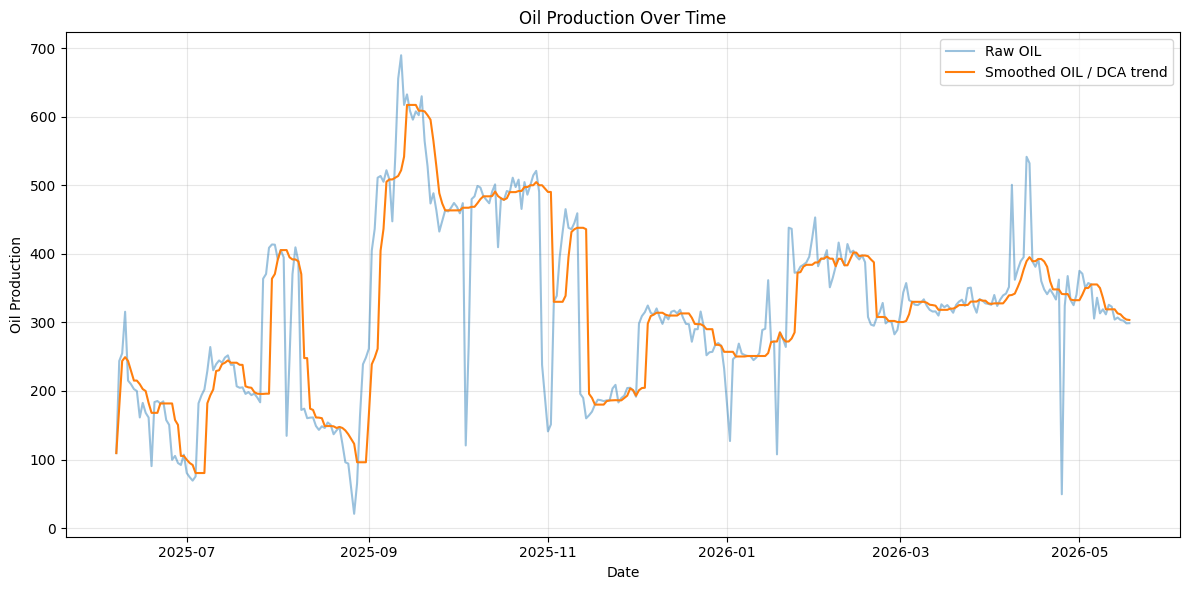

Saved feature dataset to: /home/rian/python_project/myvenv/dca_ml/data/rf03_dcalike_feature_dataset.csv
Feature matrix shape: (205, 27)
Target shape        : (205,)

Feature columns:
['t', 'q_current', 'logq_current', 'roll_mean_3', 'roll_median_3', 'roll_std_3', 'log_slope_3', 'roll_mean_7', 'roll_median_7', 'roll_std_7', 'log_slope_7', 'roll_mean_14', 'roll_median_14', 'roll_std_14', 'log_slope_14', 'roll_mean_30', 'roll_median_30', 'roll_std_30', 'log_slope_30', 'ratio_mean_3', 'ratio_median_3', 'ratio_mean_7', 'ratio_median_7', 'ratio_mean_14', 'ratio_median_14', 'ratio_mean_30', 'ratio_median_30']
Best CV RMSE on decline ratio: 0.104387
Best Params: {'n_estimators': 120, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': None}

Test performance on smoothed OIL converted from predicted decline ratio
Test OIL MAE : 4.5479
Test OIL MSE : 27.0328
Test OIL RMSE: 5.1993
Test OIL R2  : 0.9461


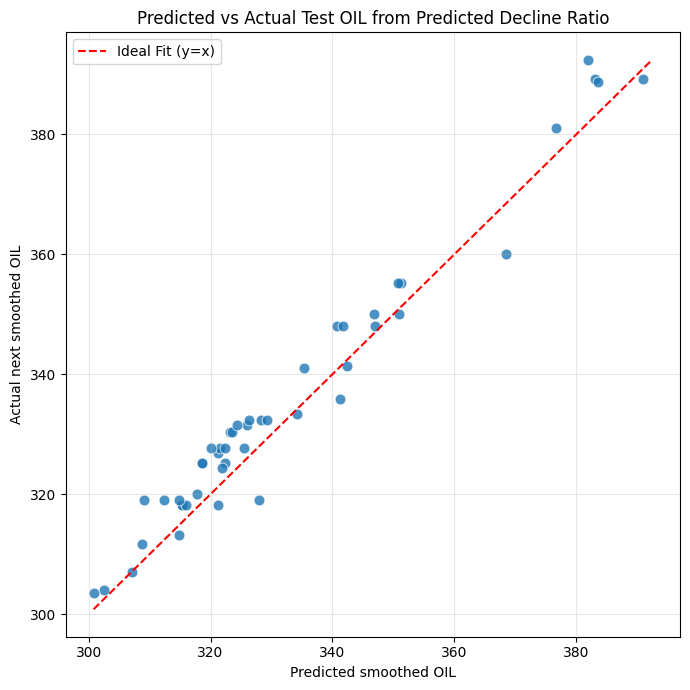

Saved recursive forecast to: /home/rian/python_project/myvenv/dca_ml/data/rf03_dcalike_recursive_forecast.csv

Forecast summary
Last smoothed oil       : 304.0705
Day-1 forecast oil      : 300.8202
Final forecast oil      : 1.0000
Forecast steps generated: 105
Mean predicted D        : 0.05458838 per day

First 10 forecast rows:
   TEST_DATE  PRED_DEC_RATIO  FORECAST_OIL
0 2026-05-18        0.010747    300.820179
1 2026-05-19        0.009743    297.903595
2 2026-05-20        0.012266    294.271900
3 2026-05-21        0.021407    288.039254
4 2026-05-22        0.026185    280.594908
5 2026-05-23        0.025397    273.558391
6 2026-05-24        0.026309    266.455166
7 2026-05-25        0.025623    259.714584
8 2026-05-26        0.024687    253.381473
9 2026-05-27        0.022076    247.849141


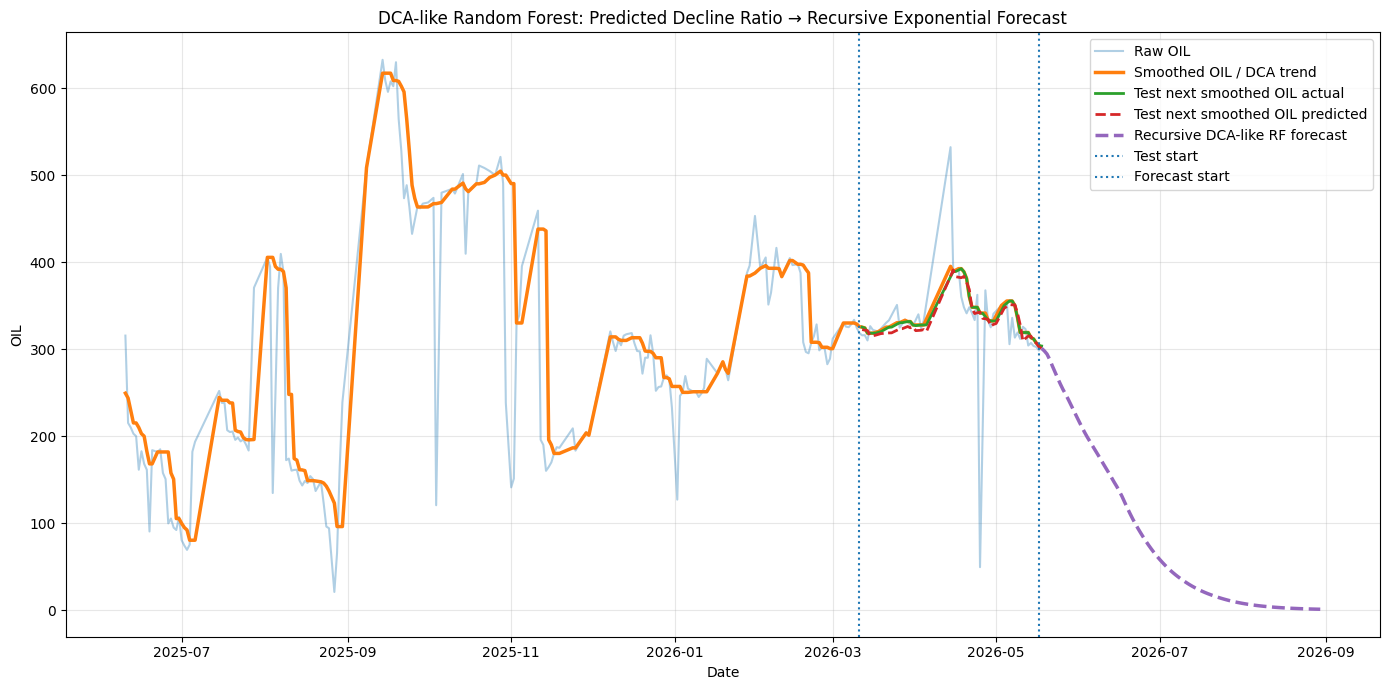

Saved plot to: /home/rian/python_project/myvenv/dca_ml/data/rf03_dcalike_recursive_forecast.png


In [44]:
def main():
    # Load data
    path = "/home/rian/python_project/myvenv/dca_ml/data/test_data.csv"
    df = load_data(path)

    # Visualize raw vs smoothed oil
    visualize_data(df, save_path="/home/rian/python_project/myvenv/dca_ml/Images/rf03_raw_vs_smooth.png")

    # Build the supervised dataset using engineered features from smoothed oil history.
    # The target remains the DCA-style decline ratio.
    minimum_history = 30
    X_all, y_all, target_indices, model_df = create_dataset(df, minimum_history=minimum_history)

    # Save feature dataset for inspection
    dataset_out = X_all.copy()
    dataset_out["DEC_RATIO_TARGET"] = y_all
    dataset_out["TEST_DATE"] = model_df["TEST_DATE"].iloc[target_indices].to_numpy()
    dataset_out["OIL_SMOOTH"] = model_df["OIL_SMOOTH"].iloc[target_indices].to_numpy()
    dataset_out["OIL_NEXT"] = model_df["OIL_NEXT"].iloc[target_indices].to_numpy()
    dataset_out["DELTA_T"] = model_df["DELTA_T"].iloc[target_indices].to_numpy()

    dataset_path = "/home/rian/python_project/myvenv/dca_ml/data/rf03_dcalike_feature_dataset.csv"
    dataset_out.to_csv(dataset_path, index=False)

    print(f"Saved feature dataset to: {dataset_path}")
    print(f"Feature matrix shape: {X_all.shape}")
    print(f"Target shape        : {y_all.shape}")
    print("\nFeature columns:")
    print(list(X_all.columns))

    # Split data with 80% for training and 20% for testing.
    # This keeps the original rf03 style: train/test split is based on chronological index.
    train_size = int(len(model_df) * 0.8)
    train_mask = target_indices < train_size
    test_mask = ~train_mask

    X_train, y_train = X_all.loc[train_mask], y_all[train_mask]
    X_test, y_test = X_all.loc[test_mask], y_all[test_mask]
    test_target_indices = target_indices[test_mask]

    # Train with time-series CV using randomized hyperparameter search.
    # This preserves the original rf03 training idea; only the input features changed.
    if len(X_train) >= 20:
        n_splits = min(5, len(X_train) - 1)
        tscv = TimeSeriesSplit(n_splits=n_splits)

        base_model = RandomForestRegressor(random_state=42, n_jobs=1)
        param_distributions = {
            "n_estimators": [120, 200, 300],
            "max_depth": [None, 5, 10, 20, 30],
            "min_samples_split": [2, 5, 10],
            "min_samples_leaf": [1, 2, 4],
            "max_features": ["sqrt", "log2", 0.8],
        }

        search = RandomizedSearchCV(
            estimator=base_model,
            param_distributions=param_distributions,
            n_iter=5,
            scoring="neg_mean_squared_error",
            cv=tscv,
            random_state=42,
            n_jobs=1,
            verbose=0,
        )
        search.fit(X_train, y_train)

        model = search.best_estimator_
        best_cv_rmse = np.sqrt(-search.best_score_)
        print(f"Best CV RMSE on decline ratio: {best_cv_rmse:.6f}")
        print(f"Best Params: {search.best_params_}")
    else:
        print("Not enough training samples for CV search. Using default RandomForestRegressor.")
        model = RandomForestRegressor(
            n_estimators=300,
            random_state=42,
            n_jobs=1,
        )
        model.fit(X_train, y_train)

    # Predict test decline ratio, then convert to OIL using exponential decline:
    # q(t+1) = q(t) * exp(-D_pred * delta_t)
    predicted_test_dec_ratio = model.predict(X_test)
    predicted_test_dec_ratio = np.clip(predicted_test_dec_ratio, 0.0, None)

    oil_at_t = model_df["OIL_SMOOTH"].iloc[test_target_indices].to_numpy()
    test_delta_t = model_df["DELTA_T"].iloc[test_target_indices].to_numpy()
    predicted_test_oil = oil_at_t * np.exp(-predicted_test_dec_ratio * test_delta_t)
    actual_test_oil = model_df["OIL_NEXT"].iloc[test_target_indices].to_numpy()
    test_dates = model_df["NEXT_TEST_DATE"].iloc[test_target_indices].to_numpy()

    # Evaluate predictive performance on test smoothed-OIL values.
    test_mse = mean_squared_error(actual_test_oil, predicted_test_oil)
    test_rmse = np.sqrt(test_mse)
    test_mae = mean_absolute_error(actual_test_oil, predicted_test_oil)
    test_r2 = r2_score(actual_test_oil, predicted_test_oil)
    print("\nTest performance on smoothed OIL converted from predicted decline ratio")
    print(f"Test OIL MAE : {test_mae:.4f}")
    print(f"Test OIL MSE : {test_mse:.4f}")
    print(f"Test OIL RMSE: {test_rmse:.4f}")
    print(f"Test OIL R2  : {test_r2:.4f}")

    # Scatter plot: Predicted OIL vs Actual OIL on test set.
    plt.figure(figsize=(7, 7))
    sns.scatterplot(x=predicted_test_oil, y=actual_test_oil, s=60, alpha=0.8)
    min_oil = min(predicted_test_oil.min(), actual_test_oil.min())
    max_oil = max(predicted_test_oil.max(), actual_test_oil.max())
    plt.plot([min_oil, max_oil], [min_oil, max_oil], "r--", linewidth=1.5, label="Ideal Fit (y=x)")
    plt.title("Predicted vs Actual Test OIL from Predicted Decline Ratio")
    plt.xlabel("Predicted smoothed OIL")
    plt.ylabel("Actual next smoothed OIL")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("/home/rian/python_project/myvenv/dca_ml/Images/rf03_predicted_vs_actual.png", dpi=200, bbox_inches="tight")
    plt.show()

    # Recursive DCA-like forecast:
    # 1. Build features from the current oil-rate history.
    # 2. Predict positive decline ratio D.
    # 3. Convert D into next oil rate using q_next = q_current * exp(-D * delta_t).
    future_oil_predictions = []
    future_dates = []
    future_decline_ratios = []

    q_history = model_df["OIL_SMOOTH"].to_numpy(dtype=float).tolist()
    q_t = q_history[-1]

    freq = pd.infer_freq(model_df["TEST_DATE"]) or "D"
    date_offset = pd.tseries.frequencies.to_offset(freq)
    current_date = model_df["TEST_DATE"].iloc[-1]

    stop_oil = 1.0
    max_forecast_steps = 1000

    for step in range(max_forecast_steps):
        idx = len(q_history) - 1
        X_future = pd.DataFrame([build_features(q_history, idx)])
        X_future = X_future[X_all.columns]

        pred_dec_ratio = float(model.predict(X_future)[0])
        pred_dec_ratio = max(pred_dec_ratio, 0.0)  # DCA decline-only constraint

        next_date = current_date + date_offset
        step_t = (next_date - current_date) / np.timedelta64(1, "D")
        if step_t <= 0:
            step_t = 1.0

        # Core DCA-like recursive equation.
        q_next = q_t * np.exp(-pred_dec_ratio * step_t)
        q_next = max(q_next, stop_oil)

        future_decline_ratios.append(pred_dec_ratio)
        future_oil_predictions.append(q_next)
        future_dates.append(next_date)

        q_history.append(q_next)
        q_t = q_next
        current_date = next_date

        if q_t <= stop_oil:
            break

    forecast_df = pd.DataFrame({
        "TEST_DATE": future_dates,
        "PRED_DEC_RATIO": future_decline_ratios,
        "FORECAST_OIL": future_oil_predictions,
    })

    forecast_path = "/home/rian/python_project/myvenv/dca_ml/data/rf03_dcalike_recursive_forecast.csv"
    forecast_df.to_csv(forecast_path, index=False)

    print(f"Saved recursive forecast to: {forecast_path}")
    print("\nForecast summary")
    print(f"Last smoothed oil       : {model_df['OIL_SMOOTH'].iloc[-1]:.4f}")
    if len(forecast_df) > 0:
        print(f"Day-1 forecast oil      : {forecast_df['FORECAST_OIL'].iloc[0]:.4f}")
        print(f"Final forecast oil      : {forecast_df['FORECAST_OIL'].iloc[-1]:.4f}")
        print(f"Forecast steps generated: {len(forecast_df)}")
        print(f"Mean predicted D        : {forecast_df['PRED_DEC_RATIO'].mean():.8f} per day")
        print("\nFirst 10 forecast rows:")
        print(forecast_df.head(10))

    # Single combined plot: historical OIL, smoothed OIL, test actual/predicted OIL, and recursive forecast.
    plt.figure(figsize=(14, 7))
    plt.plot(model_df["TEST_DATE"], model_df["OIL"], label="Raw OIL", linewidth=1.5, alpha=0.35)
    plt.plot(model_df["TEST_DATE"], model_df["OIL_SMOOTH"], label="Smoothed OIL / DCA trend", linewidth=2.5)

    if len(test_dates) > 0:
        plt.plot(test_dates, actual_test_oil, label="Test next smoothed OIL actual", linewidth=2)
        plt.plot(test_dates, predicted_test_oil, label="Test next smoothed OIL predicted", linewidth=2, linestyle="--")

    if len(forecast_df) > 0:
        plt.plot(forecast_df["TEST_DATE"], forecast_df["FORECAST_OIL"], label="Recursive DCA-like RF forecast", linewidth=2.5, linestyle="--")

    plt.axvline(model_df["TEST_DATE"].iloc[train_size], linestyle=":", label="Test start")
    plt.axvline(model_df["TEST_DATE"].iloc[-1], linestyle=":", label="Forecast start")
    plt.title("DCA-like Random Forest: Predicted Decline Ratio → Recursive Exponential Forecast")
    plt.xlabel("Date")
    plt.ylabel("OIL")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()

    plot_path = "/home/rian/python_project/myvenv/dca_ml/data/rf03_dcalike_recursive_forecast.png"
    plt.savefig(plot_path, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved plot to: {plot_path}")

    return {
        "model": model,
        "X_all": X_all,
        "y_all": y_all,
        "model_df": model_df,
        "forecast_df": forecast_df,
    }


if __name__ == "__main__":
    main()
